# Project Summary Figures

This notebook creates a small set of project-level summary figures for GitHub, presentation, and interview use.

The figures consolidate finalized results from the sealed strategy-analysis notebooks.

No new strategy optimization, parameter selection, or backtest is performed here.

---

## Figure 1 — Cross-Market Rolling OOS Comparison

This figure compares the finalized rolling out-of-sample results for:

- CBOT Soybeans (SY), from Task 5;
- SHFE Gold Futures (AUG), from Task K.

Only normalized performance measures are compared because the two markets use different currencies, histories, and contract economics.

The comparison includes:

- CAGR;
- Daily Sharpe Ratio;
- Maximum Drawdown (%);
- Calmar Ratio.

CROSS-MARKET FINALIZED ROLLING OOS RESULTS


,Market,CAGR,Daily_Sharpe,Max_Drawdown_Pct,Calmar
0,SY — Soybeans,0.033600,1.345000,-0.067900,0.495300
1,AUG — Gold Futures,0.825766,3.608593,-0.099059,8.336143



FIGURE 1 INPUT VALIDATION


,Validation Check,Passed
0,Two finalized markets included,True
1,SY CAGR positive,True
2,AUG CAGR positive,True
3,SY Sharpe positive,True
4,AUG Sharpe positive,True
5,SY drawdown negative,True
6,AUG drawdown negative,True
7,SY Calmar positive,True
8,AUG Calmar positive,True


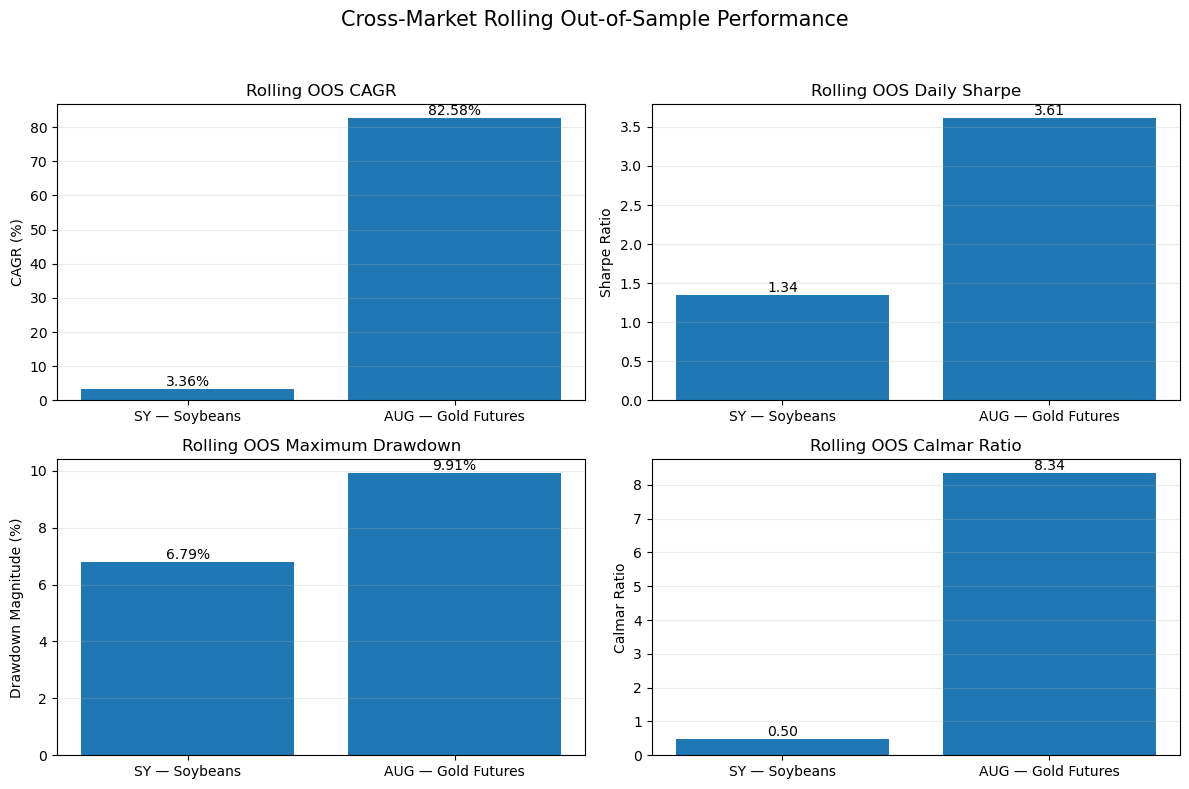


Saved Figure 1 to: figures/cross_market_oos_comparison.png
FIGURE 1 COMPLETE.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Finalized Rolling OOS Results
# ============================================================

cross_market = pd.DataFrame(
    {
        "Market": [
            "SY — Soybeans",
            "AUG — Gold Futures",
        ],

        "CAGR": [
            0.0336,
            0.825766,
        ],

        "Daily_Sharpe": [
            1.3450,
            3.608593,
        ],

        "Max_Drawdown_Pct": [
            -0.0679,
            -0.099059,
        ],

        "Calmar": [
            0.4953,
            8.336143,
        ],
    }
)


print("=" * 90)
print("CROSS-MARKET FINALIZED ROLLING OOS RESULTS")
print("=" * 90)

display(cross_market)


# ============================================================
# 2. Hard Validation
# ============================================================

checks = pd.DataFrame(
    {
        "Validation Check": [
            "Two finalized markets included",
            "SY CAGR positive",
            "AUG CAGR positive",
            "SY Sharpe positive",
            "AUG Sharpe positive",
            "SY drawdown negative",
            "AUG drawdown negative",
            "SY Calmar positive",
            "AUG Calmar positive",
        ],

        "Passed": [
            len(cross_market) == 2,

            cross_market.loc[
                cross_market["Market"] == "SY — Soybeans",
                "CAGR"
            ].iloc[0] > 0,

            cross_market.loc[
                cross_market["Market"] == "AUG — Gold Futures",
                "CAGR"
            ].iloc[0] > 0,

            cross_market.loc[
                cross_market["Market"] == "SY — Soybeans",
                "Daily_Sharpe"
            ].iloc[0] > 0,

            cross_market.loc[
                cross_market["Market"] == "AUG — Gold Futures",
                "Daily_Sharpe"
            ].iloc[0] > 0,

            cross_market.loc[
                cross_market["Market"] == "SY — Soybeans",
                "Max_Drawdown_Pct"
            ].iloc[0] < 0,

            cross_market.loc[
                cross_market["Market"] == "AUG — Gold Futures",
                "Max_Drawdown_Pct"
            ].iloc[0] < 0,

            cross_market.loc[
                cross_market["Market"] == "SY — Soybeans",
                "Calmar"
            ].iloc[0] > 0,

            cross_market.loc[
                cross_market["Market"] == "AUG — Gold Futures",
                "Calmar"
            ].iloc[0] > 0,
        ],
    }
)


print()
print("=" * 90)
print("FIGURE 1 INPUT VALIDATION")
print("=" * 90)

display(checks)

assert checks["Passed"].all()


# ============================================================
# 3. Prepare Plot Values
# ============================================================

markets = cross_market["Market"].tolist()

cagr_pct = (
    cross_market["CAGR"]
    * 100
)

sharpe = (
    cross_market["Daily_Sharpe"]
)

mdd_pct = (
    cross_market["Max_Drawdown_Pct"]
    .abs()
    * 100
)

calmar = (
    cross_market["Calmar"]
)


# ============================================================
# 4. Create 2 × 2 Summary Figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)


# ------------------------------------------------------------
# Panel A — CAGR
# ------------------------------------------------------------

axes[0, 0].bar(
    markets,
    cagr_pct
)

axes[0, 0].set_title(
    "Rolling OOS CAGR"
)

axes[0, 0].set_ylabel(
    "CAGR (%)"
)

axes[0, 0].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(cagr_pct):
    axes[0, 0].text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# Panel B — Daily Sharpe
# ------------------------------------------------------------

axes[0, 1].bar(
    markets,
    sharpe
)

axes[0, 1].set_title(
    "Rolling OOS Daily Sharpe"
)

axes[0, 1].set_ylabel(
    "Sharpe Ratio"
)

axes[0, 1].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(sharpe):
    axes[0, 1].text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# Panel C — Maximum Drawdown
#
# Plot magnitude for easier visual comparison.
# ------------------------------------------------------------

axes[1, 0].bar(
    markets,
    mdd_pct
)

axes[1, 0].set_title(
    "Rolling OOS Maximum Drawdown"
)

axes[1, 0].set_ylabel(
    "Drawdown Magnitude (%)"
)

axes[1, 0].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(mdd_pct):
    axes[1, 0].text(
        i,
        value,
        f"{value:.2f}%",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# Panel D — Calmar
# ------------------------------------------------------------

axes[1, 1].bar(
    markets,
    calmar
)

axes[1, 1].set_title(
    "Rolling OOS Calmar Ratio"
)

axes[1, 1].set_ylabel(
    "Calmar Ratio"
)

axes[1, 1].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(calmar):
    axes[1, 1].text(
        i,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )


# ============================================================
# 5. Figure-Level Formatting
# ============================================================

fig.suptitle(
    "Cross-Market Rolling Out-of-Sample Performance",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)


# ============================================================
# 6. Save Figure
# ============================================================

FIG_DIR = Path("figures")

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_PATH = (
    FIG_DIR
    /
    "cross_market_oos_comparison.png"
)

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()
print(
    f"Saved Figure 1 to: {FIG_PATH}"
)

print(
    "FIGURE 1 COMPLETE."
)

## Figure 2 — AUG Robustness Diagnostics

The exceptionally strong AUG rolling OOS result requires additional robustness diagnostics before it can be interpreted.

This figure consolidates four finalized diagnostics from the AUG analysis:

1. **Quarter-level P&L concentration** — how much of total OOS profit is attributable to the largest-performing quarters;
2. **Session-gap attribution** — how much OOS P&L is associated with bars spanning session gaps;
3. **Non-gap diagnostic performance** — whether profitability remains after excluding session-gap P&L attribution;
4. **Stop-parameter boundary behavior** — whether the optimized stop percentage is identified inside the prescribed parameter grid.

These diagnostics do not modify the finalized Task K backtest. They summarize limitations already identified in the robustness analysis.

FINALIZED AUG ROBUSTNESS DIAGNOSTICS


,Diagnostic,Value
0,Largest quarter share,0.410604
1,Top-3 quarter share,0.631136
2,Session-gap P&L share,0.766696
3,Non-gap P&L share,0.233304
4,Baseline CAGR,0.825766
5,Non-gap diagnostic CAGR,0.339955
6,Baseline Calmar,8.336143
7,Non-gap diagnostic Calmar,2.699387
8,Baseline MDD,-0.099059
9,Non-gap diagnostic MDD,-0.125938



FIGURE 2 INPUT VALIDATION


,Validation Check,Passed
0,Largest-quarter share between 0 and 1,True
1,Top-3 share between 0 and 1,True
2,Top-3 share >= largest-quarter share,True
3,Gap and non-gap P&L shares sum to 1,True
4,Baseline CAGR positive,True
5,Non-gap diagnostic CAGR positive,True
6,Baseline Calmar positive,True
7,Non-gap diagnostic Calmar positive,True
8,Baseline MDD negative,True
9,Non-gap diagnostic MDD negative,True


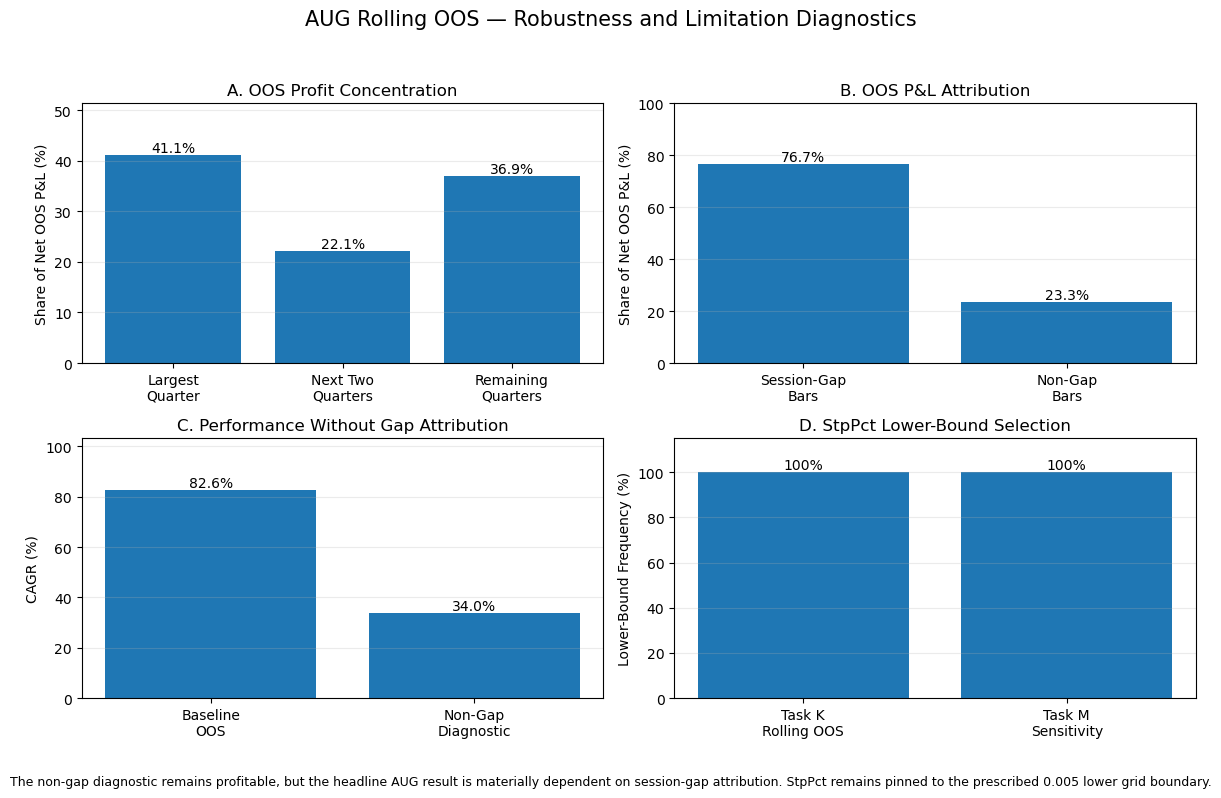


Saved Figure 2 to: figures/aug_robustness_diagnostics.png
FIGURE 2 COMPLETE.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


# ============================================================
# 1. Finalized AUG Diagnostic Inputs
# ============================================================

AUG_DIAGNOSTICS = {
    # Temporal concentration
    "Largest_Quarter_Share": 0.410604,
    "Top3_Quarter_Share": 0.631136,

    # Session-gap attribution
    "Session_Gap_PnL_Share": 0.766696,
    "Non_Gap_PnL_Share": 0.233304,

    # Baseline vs diagnostic performance
    "Baseline_CAGR": 0.825766,
    "Non_Gap_CAGR": 0.339955,

    "Baseline_Calmar": 8.336143,
    "Non_Gap_Calmar": 2.699387,

    "Baseline_MDD_Pct": -0.099059,
    "Non_Gap_MDD_Pct": -0.125938,

    # Parameter boundary
    "StpPct_Lower_Bound": 0.005,
    "Task_K_Lower_Bound_Frequency": 1.0,
    "Task_M_Lower_Bound_Frequency_Min": 1.0,
    "Task_M_Lower_Bound_Frequency_Max": 1.0,
}


diagnostic_table = pd.DataFrame(
    {
        "Diagnostic": [
            "Largest quarter share",
            "Top-3 quarter share",
            "Session-gap P&L share",
            "Non-gap P&L share",
            "Baseline CAGR",
            "Non-gap diagnostic CAGR",
            "Baseline Calmar",
            "Non-gap diagnostic Calmar",
            "Baseline MDD",
            "Non-gap diagnostic MDD",
            "Task K StpPct lower-bound frequency",
            "Task M StpPct lower-bound frequency minimum",
            "Task M StpPct lower-bound frequency maximum",
        ],

        "Value": [
            AUG_DIAGNOSTICS["Largest_Quarter_Share"],
            AUG_DIAGNOSTICS["Top3_Quarter_Share"],
            AUG_DIAGNOSTICS["Session_Gap_PnL_Share"],
            AUG_DIAGNOSTICS["Non_Gap_PnL_Share"],
            AUG_DIAGNOSTICS["Baseline_CAGR"],
            AUG_DIAGNOSTICS["Non_Gap_CAGR"],
            AUG_DIAGNOSTICS["Baseline_Calmar"],
            AUG_DIAGNOSTICS["Non_Gap_Calmar"],
            AUG_DIAGNOSTICS["Baseline_MDD_Pct"],
            AUG_DIAGNOSTICS["Non_Gap_MDD_Pct"],
            AUG_DIAGNOSTICS["Task_K_Lower_Bound_Frequency"],
            AUG_DIAGNOSTICS["Task_M_Lower_Bound_Frequency_Min"],
            AUG_DIAGNOSTICS["Task_M_Lower_Bound_Frequency_Max"],
        ],
    }
)


print("=" * 95)
print("FINALIZED AUG ROBUSTNESS DIAGNOSTICS")
print("=" * 95)

display(diagnostic_table)


# ============================================================
# 2. Hard Validation
# ============================================================

checks = pd.DataFrame(
    {
        "Validation Check": [
            "Largest-quarter share between 0 and 1",
            "Top-3 share between 0 and 1",
            "Top-3 share >= largest-quarter share",
            "Gap and non-gap P&L shares sum to 1",
            "Baseline CAGR positive",
            "Non-gap diagnostic CAGR positive",
            "Baseline Calmar positive",
            "Non-gap diagnostic Calmar positive",
            "Baseline MDD negative",
            "Non-gap diagnostic MDD negative",
            "Task K stop lower-bound frequency equals 100%",
            "Task M minimum stop lower-bound frequency equals 100%",
            "Task M maximum stop lower-bound frequency equals 100%",
        ],

        "Passed": [
            (
                0
                <= AUG_DIAGNOSTICS["Largest_Quarter_Share"]
                <= 1
            ),

            (
                0
                <= AUG_DIAGNOSTICS["Top3_Quarter_Share"]
                <= 1
            ),

            (
                AUG_DIAGNOSTICS["Top3_Quarter_Share"]
                >=
                AUG_DIAGNOSTICS["Largest_Quarter_Share"]
            ),

            np.isclose(
                AUG_DIAGNOSTICS["Session_Gap_PnL_Share"]
                +
                AUG_DIAGNOSTICS["Non_Gap_PnL_Share"],
                1.0,
                rtol=0.0,
                atol=1e-12
            ),

            AUG_DIAGNOSTICS["Baseline_CAGR"] > 0,

            AUG_DIAGNOSTICS["Non_Gap_CAGR"] > 0,

            AUG_DIAGNOSTICS["Baseline_Calmar"] > 0,

            AUG_DIAGNOSTICS["Non_Gap_Calmar"] > 0,

            AUG_DIAGNOSTICS["Baseline_MDD_Pct"] < 0,

            AUG_DIAGNOSTICS["Non_Gap_MDD_Pct"] < 0,

            np.isclose(
                AUG_DIAGNOSTICS[
                    "Task_K_Lower_Bound_Frequency"
                ],
                1.0
            ),

            np.isclose(
                AUG_DIAGNOSTICS[
                    "Task_M_Lower_Bound_Frequency_Min"
                ],
                1.0
            ),

            np.isclose(
                AUG_DIAGNOSTICS[
                    "Task_M_Lower_Bound_Frequency_Max"
                ],
                1.0
            ),
        ],
    }
)


print()
print("=" * 95)
print("FIGURE 2 INPUT VALIDATION")
print("=" * 95)

display(checks)

assert checks["Passed"].all()


# ============================================================
# 3. Prepare Derived Values
# ============================================================

largest_quarter = (
    100
    *
    AUG_DIAGNOSTICS["Largest_Quarter_Share"]
)

next_two_quarters = (
    100
    *
    (
        AUG_DIAGNOSTICS["Top3_Quarter_Share"]
        -
        AUG_DIAGNOSTICS["Largest_Quarter_Share"]
    )
)

remaining_quarters = (
    100
    *
    (
        1
        -
        AUG_DIAGNOSTICS["Top3_Quarter_Share"]
    )
)


gap_share = (
    100
    *
    AUG_DIAGNOSTICS["Session_Gap_PnL_Share"]
)

non_gap_share = (
    100
    *
    AUG_DIAGNOSTICS["Non_Gap_PnL_Share"]
)


baseline_cagr = (
    100
    *
    AUG_DIAGNOSTICS["Baseline_CAGR"]
)

non_gap_cagr = (
    100
    *
    AUG_DIAGNOSTICS["Non_Gap_CAGR"]
)


task_k_boundary = (
    100
    *
    AUG_DIAGNOSTICS[
        "Task_K_Lower_Bound_Frequency"
    ]
)

task_m_boundary = (
    100
    *
    AUG_DIAGNOSTICS[
        "Task_M_Lower_Bound_Frequency_Min"
    ]
)


# ============================================================
# 4. Create 2 × 2 Diagnostic Figure
# ============================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)


# ------------------------------------------------------------
# Panel A — Quarter-Level P&L Concentration
#
# IMPORTANT:
# Categories are mutually exclusive:
# largest quarter
# next two largest quarters
# all remaining quarters
# ------------------------------------------------------------

quarter_labels = [
    "Largest\nQuarter",
    "Next Two\nQuarters",
    "Remaining\nQuarters",
]

quarter_values = [
    largest_quarter,
    next_two_quarters,
    remaining_quarters,
]

axes[0, 0].bar(
    quarter_labels,
    quarter_values
)

axes[0, 0].set_title(
    "A. OOS Profit Concentration"
)

axes[0, 0].set_ylabel(
    "Share of Net OOS P&L (%)"
)

axes[0, 0].set_ylim(
    0,
    max(quarter_values) * 1.25
)

axes[0, 0].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(quarter_values):
    axes[0, 0].text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# Panel B — Session-Gap Attribution
# ------------------------------------------------------------

gap_labels = [
    "Session-Gap\nBars",
    "Non-Gap\nBars",
]

gap_values = [
    gap_share,
    non_gap_share,
]

axes[0, 1].bar(
    gap_labels,
    gap_values
)

axes[0, 1].set_title(
    "B. OOS P&L Attribution"
)

axes[0, 1].set_ylabel(
    "Share of Net OOS P&L (%)"
)

axes[0, 1].set_ylim(
    0,
    100
)

axes[0, 1].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(gap_values):
    axes[0, 1].text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# Panel C — Baseline vs Non-Gap CAGR
# ------------------------------------------------------------

cagr_labels = [
    "Baseline\nOOS",
    "Non-Gap\nDiagnostic",
]

cagr_values = [
    baseline_cagr,
    non_gap_cagr,
]

axes[1, 0].bar(
    cagr_labels,
    cagr_values
)

axes[1, 0].set_title(
    "C. Performance Without Gap Attribution"
)

axes[1, 0].set_ylabel(
    "CAGR (%)"
)

axes[1, 0].set_ylim(
    0,
    max(cagr_values) * 1.25
)

axes[1, 0].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(cagr_values):
    axes[1, 0].text(
        i,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )


# ------------------------------------------------------------
# Panel D — Stop Parameter Boundary
# ------------------------------------------------------------

boundary_labels = [
    "Task K\nRolling OOS",
    "Task M\nSensitivity",
]

boundary_values = [
    task_k_boundary,
    task_m_boundary,
]

axes[1, 1].bar(
    boundary_labels,
    boundary_values
)

axes[1, 1].set_title(
    "D. StpPct Lower-Bound Selection"
)

axes[1, 1].set_ylabel(
    "Lower-Bound Frequency (%)"
)

axes[1, 1].set_ylim(
    0,
    115
)

axes[1, 1].grid(
    axis="y",
    alpha=0.25
)

for i, value in enumerate(boundary_values):
    axes[1, 1].text(
        i,
        value,
        f"{value:.0f}%",
        ha="center",
        va="bottom"
    )


# ============================================================
# 5. Figure-Level Formatting
# ============================================================

fig.suptitle(
    "AUG Rolling OOS — Robustness and Limitation Diagnostics",
    fontsize=15
)

fig.text(
    0.5,
    0.01,
    (
        "The non-gap diagnostic remains profitable, but the "
        "headline AUG result is materially dependent on "
        "session-gap attribution. StpPct remains pinned to "
        "the prescribed 0.005 lower grid boundary."
    ),
    ha="center",
    fontsize=9
)

plt.tight_layout(
    rect=[0, 0.05, 1, 0.95]
)


# ============================================================
# 6. Save Figure
# ============================================================

FIG_DIR = Path("figures")

FIG_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIG_PATH = (
    FIG_DIR
    /
    "aug_robustness_diagnostics.png"
)

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print()
print(
    f"Saved Figure 2 to: {FIG_PATH}"
)

print(
    "FIGURE 2 COMPLETE."
)